# **Points durs**

In [ ]:
# =====================================================
# 0. INSTALL
# =====================================================
!pip install geopandas pandas fiona pyproj shapely

# =====================================================
# 1. IMPORTS
# =====================================================
import os
import geopandas as gpd
import pandas as pd

# =====================================================
# 2. LISTER LES GEOJSON
# =====================================================
files = [f for f in os.listdir() if f.endswith(".geojson")]

print("Nombre de fichiers :", len(files))

# =====================================================
# 3. FONCTION EXTRACTION INFO
# =====================================================
def extract_info(filename):
    name = filename.replace(".geojson","").replace(" ", "_")
    parts = name.split("_")

    code = parts[0]
    type_epci = parts[1]

    # récupérer territoire propre
    territoire = "_".join(parts[2:parts.index("2021")] if "2021" in parts else parts[2:parts.index("2025")])

    annee = 2021 if "2021" in parts else 2025

    description = "points_rouges" if "points-rouges" in filename else "points_noirs"

    return code, type_epci, territoire, annee, description

# =====================================================
# 4. TRAITEMENT
# =====================================================
gdfs = []

for file in files:

    try:
        gdf = gpd.read_file(file)
    except:
        print("Erreur lecture :", file)
        continue

    print("\n==========================")
    print("Fichier :", file)
    print("Nb attributs :", len(gdf.columns))
    print("Colonnes :", list(gdf.columns))

    # CRS
    if gdf.crs is None:
        gdf.set_crs(epsg=4326, inplace=True)

    # reprojection
    gdf = gdf.to_crs(epsg=3948)

    # extraction infos
    code, type_epci, territoire, annee, description = extract_info(file)

    # ajout attributs
    gdf["code"] = code
    gdf["epci"] = territoire
    gdf["type_epci"] = type_epci
    gdf["annee"] = annee
    gdf["description"] = description

    # nettoyage colonnes
    gdf.columns = [c.lower().replace(" ", "_") for c in gdf.columns]

    # sauvegarde individuelle
    out_name = f"{code}_{territoire}_{annee}_fub.gpkg"
    gdf.to_file(out_name, driver="GPKG")

    gdfs.append(gdf)

# =====================================================
# 5. FUSION
# =====================================================
gdf_final = gpd.GeoDataFrame(
    pd.concat(gdfs, ignore_index=True),
    crs="EPSG:3948"
)

gdf_final = gdf_final[[
    "code","epci","type_epci","description","annee","geometry"
]]

# =====================================================
# 6. EXPORT FINAL
# =====================================================
final_path = "fub_points_durs_usages_3948_alsace.gpkg"

gdf_final.to_file(final_path, driver="GPKG")

print("\n==========================")
print("FICHIER FINAL CRÉÉ")
print("Colonnes :", list(gdf_final.columns))
print("Nombre total :", len(gdf_final))
print("Nom :", final_path)

Nombre de fichiers : 41

Fichier : 6805_CC_Sud_Alsace_Largue_2021_points_noirs-200066033.geojson
Nb attributs : 5
Colonnes : ['commune', 'epci', 'departement', 'region', 'geometry']

Fichier : 6815_CC_Rouffach_Vignobles_Chateaux_2025_points-rouges-246800494.geojson
Nb attributs : 6
Colonnes : ['commune', 'epci', 'departement', 'region', 'description', 'geometry']

Fichier : 6707_CC_Outre_Foret_2021_points_noirs-200040178.geojson
Nb attributs : 5
Colonnes : ['commune', 'epci', 'departement', 'region', 'geometry']

Fichier : 6711_CC_Region_Molsheim_Mutzig_2025_points-rouges-246701064.geojson
Nb attributs : 6
Colonnes : ['commune', 'epci', 'departement', 'region', 'description', 'geometry']

Fichier : 6708_CC_Basse_Zorn_2025_points-rouges-246700843.geojson
Nb attributs : 6
Colonnes : ['commune', 'epci', 'departement', 'region', 'description', 'geometry']

Fichier : 6720_CC_Pays_Sainte_Odile_2025_points-rouges-246701080.geojson
Nb attributs : 6
Colonnes : ['commune', 'epci', 'departement',

In [ ]:
# =====================================================
# 0. INSTALL
# =====================================================
!pip install geopandas pandas fiona pyproj shapely

# =====================================================
# 1. IMPORTS
# =====================================================
import os
import geopandas as gpd
import pandas as pd

# =====================================================
# 2. LISTER GEOJSON
# =====================================================
files = [f for f in os.listdir() if f.endswith(".geojson")]

print("Nombre de fichiers :", len(files))

# =====================================================
# 3. EXTRACTION INFOS FICHIER
# =====================================================
def extract_info(filename):
    name = filename.replace(".geojson","").replace(" ", "_")
    parts = name.split("_")

    code = parts[0]
    type_epci = parts[1]

    territoire = "_".join(
        parts[2:parts.index("2021")] if "2021" in parts
        else parts[2:parts.index("2025")]
    )

    annee = 2021 if "2021" in parts else 2025

    return code, type_epci, territoire, annee

# =====================================================
# 4. TRAITEMENT
# =====================================================
gdfs = []

for file in files:

    try:
        gdf = gpd.read_file(file)
    except:
        print("Erreur lecture :", file)
        continue

    print("\n==========================")
    print("Fichier :", file)
    print("Nb attributs :", len(gdf.columns))
    print("Colonnes :", list(gdf.columns))

    # garder epci original
    if "epci" in gdf.columns:
        gdf["epci_code"] = gdf["epci"]
    else:
        gdf["epci_code"] = None

    # description depuis données (2025 uniquement)
    if "description" not in gdf.columns:
        gdf["description"] = None

    # CRS
    if gdf.crs is None:
        gdf.set_crs(epsg=4326, inplace=True)

    gdf = gdf.to_crs(epsg=3948)

    # extraction
    code, type_epci, territoire, annee = extract_info(file)

    # attributs
    gdf["code"] = code
    gdf["epci_av"] = territoire
    gdf["type_epci"] = type_epci
    gdf["annee"] = annee

    # nettoyage colonnes
    gdf.columns = [c.lower().replace(" ", "_") for c in gdf.columns]

    # garder structure demandée
    gdf = gdf[[
        "code",
        "epci_av",
        "type_epci",
        "epci_code",
        "description",
        "annee",
        "geometry"
    ]]

    gdfs.append(gdf)

# =====================================================
# 5. FUSION
# =====================================================
gdf_final = gpd.GeoDataFrame(
    pd.concat(gdfs, ignore_index=True),
    crs="EPSG:3948"
)

# ajouter fid propre
gdf_final.reset_index(inplace=True)
gdf_final.rename(columns={"index":"fid"}, inplace=True)

# =====================================================
# 6. EXPORT 1
# =====================================================
gdf_final.to_file("fub_points_durs_usages_3948_alsace.gpkg", driver="GPKG")

print("\n==========================")
print("SORTIE 1 OK")
print("Colonnes :", list(gdf_final.columns))
print("Nb objets :", len(gdf_final))

# =====================================================
# 7. JOINTURE COMMUNES
# =====================================================

# charger communes
communes = gpd.read_file("_osm_commune_cea_20260402_telecharge.gpkg")

print("\nCOMMUNES")
print("Nb attributs :", len(communes.columns))
print("Colonnes :", list(communes.columns))

# vérifier CRS
if communes.crs != gdf_final.crs:
    communes = communes.to_crs(gdf_final.crs)

# jointure spatiale
join = gpd.sjoin(gdf_final, communes, predicate="intersects", how="left")

# garder attributs communes
# ⚠️ adapter si noms différents dans ton gpkg
join["nom_com"] = join["nom"] if "nom" in join.columns else None
join["insee_commue"] = join["insee_commue"] if "insee_commue" in join.columns else None

# nettoyer colonnes finales
gdf_com = join[[
    "fid",
    "code",
    "epci_av",
    "type_epci",
    "epci_code",
    "description",
    "annee",
    "nom_com",
    "insee_commune",
    "geometry"
]]

# =====================================================
# 8. EXPORT 2
# =====================================================
gdf_com.to_file("fub_points_durs_usages_com_3948_alsace.gpkg", driver="GPKG")

print("\n==========================")
print("SORTIE 2 OK")
print("Colonnes :", list(gdf_com.columns))
print("Nb objets :", len(gdf_com))

Nombre de fichiers : 41

Fichier : 6805_CC_Sud_Alsace_Largue_2021_points_noirs-200066033.geojson
Nb attributs : 5
Colonnes : ['commune', 'epci', 'departement', 'region', 'geometry']

Fichier : 6815_CC_Rouffach_Vignobles_Chateaux_2025_points-rouges-246800494.geojson
Nb attributs : 6
Colonnes : ['commune', 'epci', 'departement', 'region', 'description', 'geometry']

Fichier : 6707_CC_Outre_Foret_2021_points_noirs-200040178.geojson
Nb attributs : 5
Colonnes : ['commune', 'epci', 'departement', 'region', 'geometry']

Fichier : 6711_CC_Region_Molsheim_Mutzig_2025_points-rouges-246701064.geojson
Nb attributs : 6
Colonnes : ['commune', 'epci', 'departement', 'region', 'description', 'geometry']

Fichier : 6708_CC_Basse_Zorn_2025_points-rouges-246700843.geojson
Nb attributs : 6
Colonnes : ['commune', 'epci', 'departement', 'region', 'description', 'geometry']

Fichier : 6720_CC_Pays_Sainte_Odile_2025_points-rouges-246701080.geojson
Nb attributs : 6
Colonnes : ['commune', 'epci', 'departement',

## **Analse statistique des résultats**

## Préparation de la grille finale

In [ ]:
import geopandas as gpd
import pandas as pd

# =========================================================
# (1) CHARGEMENT
# =========================================================

grille_path = "/content/grille_alsace_sans_massifs.gpkg"
count_path = "/content/count_grille_fub.gpkg"

grille = gpd.read_file(grille_path)
count = gpd.read_file(count_path)

print("Grille récente :", len(grille))
print("Résultat FUB :", len(count))

# =========================================================
# (2) VERIFICATION DES COLONNES
# =========================================================

print(grille.columns)
print(count.columns)

# =========================================================
# (3) JOINTURE
# sur idINSPIRE
# =========================================================

grille_finale = grille.merge(
    count[
        [
            "idINSPIRE",
            "count_nb"
        ]
    ],
    on="idINSPIRE",
    how="left"
)

# =========================================================
# (4) REMPLACEMENT DES NaN
# =========================================================

grille_finale["count_nb"] = (
    grille_finale["count_nb"]
    .fillna(0)
    .astype(int)
)

# =========================================================
# (5) REDUCTION :
# garder seulement les grilles avec données
# =========================================================

grille_finale = grille_finale[
    grille_finale["count_nb"] > 0
].copy()

print("Nombre final de grilles :", len(grille_finale))

# =========================================================
# (6) EXPORT
# =========================================================

output_path = "/content/grille_finale_fub_points_durs.gpkg"

grille_finale.to_file(
    output_path,
    driver="GPKG"
)

print("Export terminé :")
print(output_path)

Grille récente : 182455
Résultat FUB : 250872
Index(['idINSPIRE', 'geometry'], dtype='object')
Index(['idINSPIRE', 'count_nb', 'geometry'], dtype='object')
Nombre final de grilles : 4132
Export terminé :
/content/grille_finale_fub_points_durs.gpkg


## **Analyse statistique avancée**


COUCHE : POINTS DURS FUB
Nombre de lignes : 4132
Nombre de colonnes : 3
CRS : EPSG:3948

APERCU
                        idINSPIRE  count_nb
0  CRS3035RES200mN2745200E4095600         1
1  CRS3035RES200mN2744400E4095600         1
2  CRS3035RES200mN2744800E4096000         1
3  CRS3035RES200mN2744400E4096000         1
4  CRS3035RES200mN2756600E4096200         1

STATISTIQUES GENERALES
count    4132.000000
mean        3.104308
std         5.599479
min         1.000000
25%         1.000000
50%         1.000000
75%         3.000000
max       114.000000
Name: count_nb, dtype: float64

INDICATEURS AVANCES
Moyenne : 3.1043078412391094
Médiane : 1.0
Ecart-type : 5.5994787278662495
Coefficient variation : 1.8037768849725846
Skewness : 8.48828352850813
Kurtosis : 115.9490926759564

DECILES / QUANTILES
0.00      1.0
0.05      1.0
0.10      1.0
0.20      1.0
0.40      1.0
0.60      2.0
0.80      4.0
0.90      6.0
0.95     10.0
0.99     25.0
1.00    114.0
Name: count_nb, dtype: float64

VALEURS EXTRE

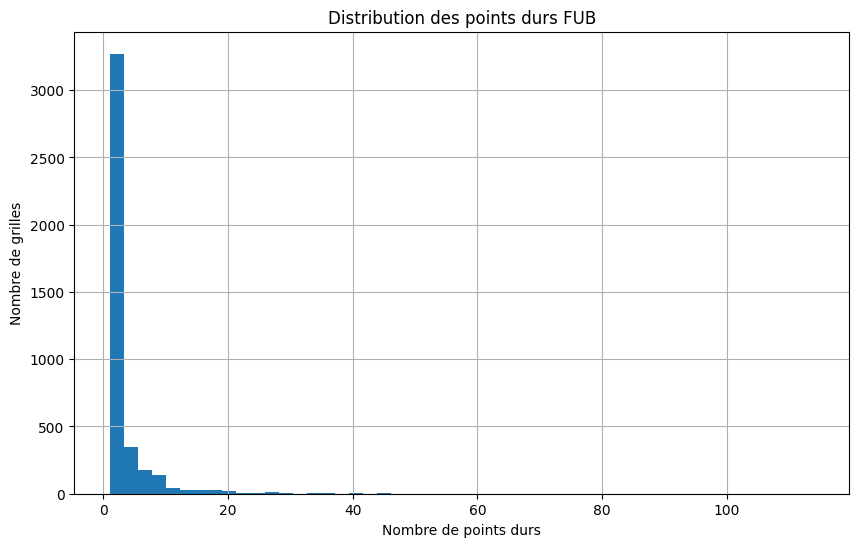

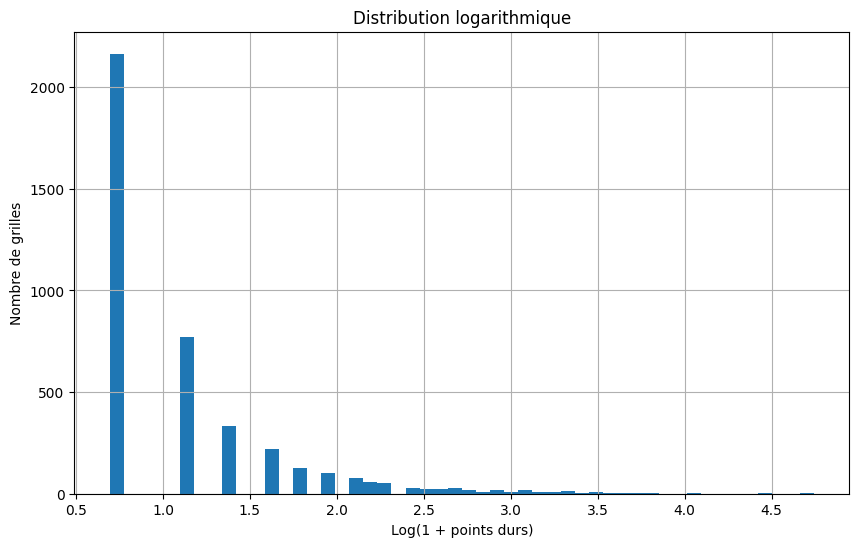

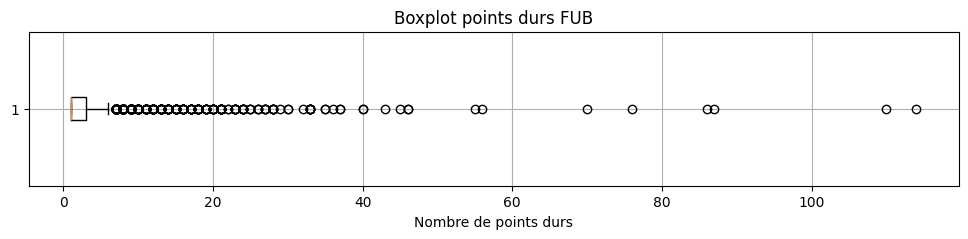


INTERPRETATION

Critères à observer :

1. Skewness
- proche de 0 :
  distribution équilibrée
- > 1 :
  forte asymétrie
  présence d'hypercentres

2. Kurtosis
- élevée :
  présence de valeurs extrêmes

3. Coefficient de variation
- élevé :
  forte hétérogénéité spatiale

4. Histogramme
- vérifier :
  - effet centre-ville
  - concentration spatiale
  - queues longues

5. Classification conseillée

Distribution équilibrée :
-> quantiles

Distribution asymétrique :
-> logarithmique
-> Jenks

Présence d'hypercentres :
-> seuils manuels
-> clipping des extrêmes



In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =========================================================
# (1) CHARGEMENT
# =========================================================

file_path = "/content/grille_finale_fub_points_durs.gpkg"

gdf = gpd.read_file(file_path)

print("\n==============================")
print("COUCHE : POINTS DURS FUB")
print("==============================")

print("Nombre de lignes :", len(gdf))
print("Nombre de colonnes :", len(gdf.columns))
print("CRS :", gdf.crs)

# =========================================================
# (2) APERCU
# =========================================================

print("\n==============================")
print("APERCU")
print("==============================")

print(
    gdf[
        [
            "idINSPIRE",
            "count_nb"
        ]
    ].head()
)

# =========================================================
# (3) STATISTIQUES GENERALES
# =========================================================

print("\n==============================")
print("STATISTIQUES GENERALES")
print("==============================")

stats = gdf["count_nb"].describe()

print(stats)

# =========================================================
# (4) INDICATEURS AVANCES
# =========================================================

print("\n==============================")
print("INDICATEURS AVANCES")
print("==============================")

mean_val = gdf["count_nb"].mean()
median_val = gdf["count_nb"].median()
std_val = gdf["count_nb"].std()

cv = std_val / mean_val

skewness = gdf["count_nb"].skew()
kurtosis = gdf["count_nb"].kurt()

print("Moyenne :", mean_val)
print("Médiane :", median_val)
print("Ecart-type :", std_val)

print("Coefficient variation :", cv)

print("Skewness :", skewness)
print("Kurtosis :", kurtosis)

# =========================================================
# (5) QUANTILES
# =========================================================

print("\n==============================")
print("DECILES / QUANTILES")
print("==============================")

quantiles = gdf["count_nb"].quantile([
    0,
    0.05,
    0.10,
    0.20,
    0.40,
    0.60,
    0.80,
    0.90,
    0.95,
    0.99,
    1
])

print(quantiles)

# =========================================================
# (6) VALEURS EXTREMES
# =========================================================

print("\n==============================")
print("VALEURS EXTREMES")
print("==============================")

q1 = gdf["count_nb"].quantile(0.25)
q3 = gdf["count_nb"].quantile(0.75)

iqr = q3 - q1

borne_sup = q3 + 1.5 * iqr

print("Q1 :", q1)
print("Q3 :", q3)
print("IQR :", iqr)

print("Seuil outlier :", borne_sup)

outliers = gdf[
    gdf["count_nb"] > borne_sup
]

print("Nombre outliers :", len(outliers))

# =========================================================
# (7) REPARTITION DES VALEURS
# =========================================================

print("\n==============================")
print("TOP VALEURS")
print("==============================")

print(
    gdf["count_nb"]
    .value_counts()
    .sort_index()
    .tail(20)
)

# =========================================================
# (8) HISTOGRAMME
# =========================================================

plt.figure(figsize=(10,6))

plt.hist(
    gdf["count_nb"],
    bins=50
)

plt.xlabel("Nombre de points durs")
plt.ylabel("Nombre de grilles")

plt.title(
    "Distribution des points durs FUB"
)

plt.grid()

plt.show()

# =========================================================
# (9) HISTOGRAMME LOG
# utile si forte asymétrie
# =========================================================

plt.figure(figsize=(10,6))

plt.hist(
    np.log1p(gdf["count_nb"]),
    bins=50
)

plt.xlabel("Log(1 + points durs)")
plt.ylabel("Nombre de grilles")

plt.title(
    "Distribution logarithmique"
)

plt.grid()

plt.show()

# =========================================================
# (10) BOXPLOT
# =========================================================

plt.figure(figsize=(12,2))

plt.boxplot(
    gdf["count_nb"],
    vert=False
)

plt.xlabel("Nombre de points durs")

plt.title(
    "Boxplot points durs FUB"
)

plt.grid()

plt.show()

# =========================================================
# (11) INTERPRETATION
# =========================================================

print("\n==============================")
print("INTERPRETATION")
print("==============================")

print("""
Critères à observer :

1. Skewness
- proche de 0 :
  distribution équilibrée
- > 1 :
  forte asymétrie
  présence d'hypercentres

2. Kurtosis
- élevée :
  présence de valeurs extrêmes

3. Coefficient de variation
- élevé :
  forte hétérogénéité spatiale

4. Histogramme
- vérifier :
  - effet centre-ville
  - concentration spatiale
  - queues longues

5. Classification conseillée

Distribution équilibrée :
-> quantiles

Distribution asymétrique :
-> logarithmique
-> Jenks

Présence d'hypercentres :
-> seuils manuels
-> clipping des extrêmes
""")

# **Accidents**

## PREPARATION GRILLE FINALE ACCIDENTS

In [ ]:
# =========================================================
# BLOC 1
# PREPARATION GRILLE FINALE ACCIDENTS
# =========================================================

import geopandas as gpd
import pandas as pd

# =========================================================
# (1) CHARGEMENT
# =========================================================

grille_path = "/content/grille_alsace_sans_massifs.gpkg"
count_path = "/content/count_grille_accident.gpkg"

grille = gpd.read_file(grille_path)
count = gpd.read_file(count_path)

print("Grille récente :", len(grille))
print("Résultat accidents :", len(count))

# =========================================================
# (2) VERIFICATION DES COLONNES
# =========================================================

print("\nColonnes grille :")
print(grille.columns)

print("\nColonnes accidents :")
print(count.columns)

# =========================================================
# (3) JOINTURE
# =========================================================

grille_finale = grille.merge(
    count[
        [
            "idINSPIRE",
            "count_nb"
        ]
    ],
    on="idINSPIRE",
    how="left"
)

# =========================================================
# (4) REMPLACEMENT NaN
# =========================================================

grille_finale["count_nb"] = (
    grille_finale["count_nb"]
    .fillna(0)
    .astype(int)
)

# =========================================================
# (5) REDUCTION
# garder seulement les grilles avec accidents
# =========================================================

grille_finale = grille_finale[
    grille_finale["count_nb"] > 0
].copy()

print("\nNombre final de grilles :", len(grille_finale))

# =========================================================
# (6) EXPORT
# =========================================================

output_path = "/content/grille_finale_accidents.gpkg"

grille_finale.to_file(
    output_path,
    driver="GPKG"
)

print("\nExport terminé :")
print(output_path)

Grille récente : 182455
Résultat accidents : 250872

Colonnes grille :
Index(['idINSPIRE', 'geometry'], dtype='object')

Colonnes accidents :
Index(['idINSPIRE', 'count_nb', 'geometry'], dtype='object')

Nombre final de grilles : 773

Export terminé :
/content/grille_finale_accidents.gpkg


## statistique des résultat


COUCHE : ACCIDENTS
Nombre de lignes : 773
Nombre de colonnes : 3
CRS : EPSG:3948

APERCU
                        idINSPIRE  count_nb
0  CRS3035RES200mN2748200E4091400         1
1  CRS3035RES200mN2767000E4094000         1
2  CRS3035RES200mN2763200E4094600         1
3  CRS3035RES200mN2757600E4095400         1
4  CRS3035RES200mN2744400E4095600         1

STATISTIQUES GENERALES
count    773.000000
mean       1.200517
std        0.552807
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        5.000000
Name: count_nb, dtype: float64

INDICATEURS AVANCES
Moyenne : 1.2005174644243208
Médiane : 1.0
Ecart-type : 0.5528070068351172
Coefficient variation : 0.4604739399607172
Skewness : 3.558174482102282
Kurtosis : 15.51832551933734

DECILES / QUANTILES
0.00    1.00
0.05    1.00
0.10    1.00
0.20    1.00
0.40    1.00
0.60    1.00
0.80    1.00
0.90    2.00
0.95    2.00
0.99    3.28
1.00    5.00
Name: count_nb, dtype: float64

VALEURS EXTREMES
Q1 : 1.0
Q3 : 1.0
IQR

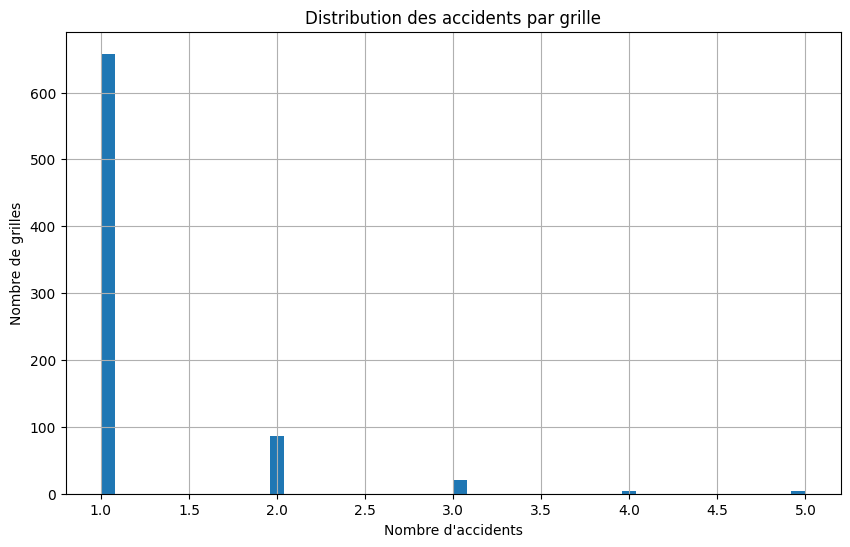

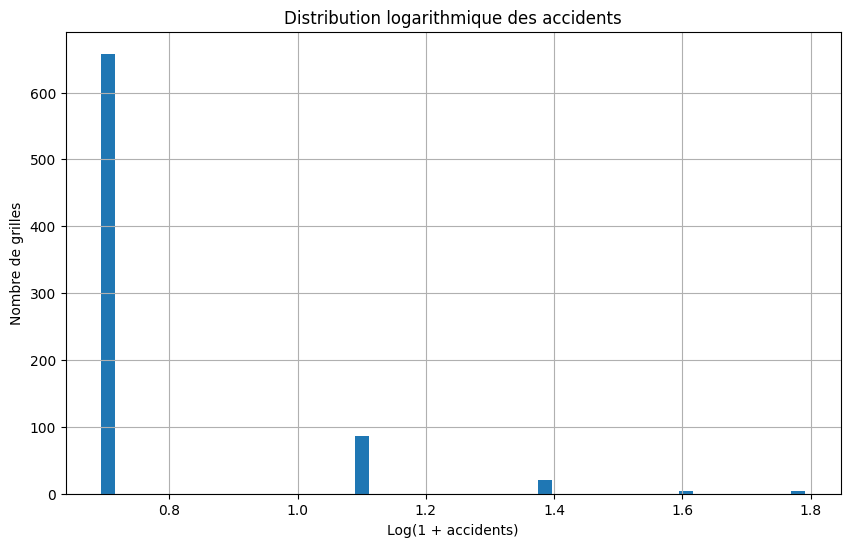

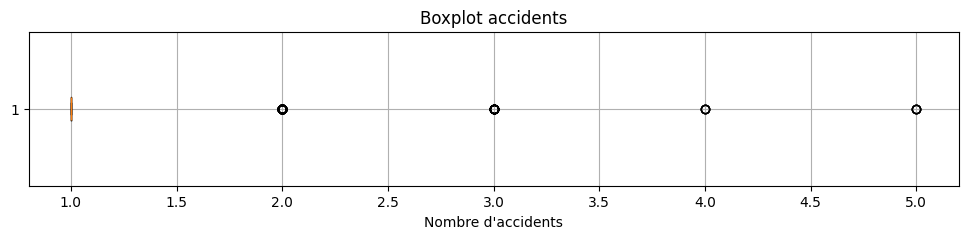

In [ ]:
# =========================================================
# BLOC 2
# ANALYSE STATISTIQUE ACCIDENTS
# =========================================================

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =========================================================
# (1) CHARGEMENT
# =========================================================

file_path = "/content/grille_finale_accidents.gpkg"

gdf = gpd.read_file(file_path)

print("\n==============================")
print("COUCHE : ACCIDENTS")
print("==============================")

print("Nombre de lignes :", len(gdf))
print("Nombre de colonnes :", len(gdf.columns))
print("CRS :", gdf.crs)

# =========================================================
# (2) APERCU
# =========================================================

print("\n==============================")
print("APERCU")
print("==============================")

print(
    gdf[
        [
            "idINSPIRE",
            "count_nb"
        ]
    ].head()
)

# =========================================================
# (3) STATISTIQUES GENERALES
# =========================================================

print("\n==============================")
print("STATISTIQUES GENERALES")
print("==============================")

stats = gdf["count_nb"].describe()

print(stats)

# =========================================================
# (4) INDICATEURS AVANCES
# =========================================================

print("\n==============================")
print("INDICATEURS AVANCES")
print("==============================")

mean_val = gdf["count_nb"].mean()
median_val = gdf["count_nb"].median()
std_val = gdf["count_nb"].std()

cv = std_val / mean_val

skewness = gdf["count_nb"].skew()
kurtosis = gdf["count_nb"].kurt()

print("Moyenne :", mean_val)
print("Médiane :", median_val)
print("Ecart-type :", std_val)

print("Coefficient variation :", cv)

print("Skewness :", skewness)
print("Kurtosis :", kurtosis)

# =========================================================
# (5) QUANTILES
# =========================================================

print("\n==============================")
print("DECILES / QUANTILES")
print("==============================")

quantiles = gdf["count_nb"].quantile([
    0,
    0.05,
    0.10,
    0.20,
    0.40,
    0.60,
    0.80,
    0.90,
    0.95,
    0.99,
    1
])

print(quantiles)

# =========================================================
# (6) VALEURS EXTREMES
# =========================================================

print("\n==============================")
print("VALEURS EXTREMES")
print("==============================")

q1 = gdf["count_nb"].quantile(0.25)
q3 = gdf["count_nb"].quantile(0.75)

iqr = q3 - q1

borne_sup = q3 + 1.5 * iqr

print("Q1 :", q1)
print("Q3 :", q3)
print("IQR :", iqr)

print("Seuil outlier :", borne_sup)

outliers = gdf[
    gdf["count_nb"] > borne_sup
]

print("Nombre outliers :", len(outliers))

# =========================================================
# (7) REPARTITION DES VALEURS
# =========================================================

print("\n==============================")
print("TOP VALEURS")
print("==============================")

print(
    gdf["count_nb"]
    .value_counts()
    .sort_index()
    .tail(20)
)

# =========================================================
# (8) HISTOGRAMME
# =========================================================

plt.figure(figsize=(10,6))

plt.hist(
    gdf["count_nb"],
    bins=50
)

plt.xlabel("Nombre d'accidents")
plt.ylabel("Nombre de grilles")

plt.title(
    "Distribution des accidents par grille"
)

plt.grid()

plt.show()

# =========================================================
# (9) HISTOGRAMME LOG
# =========================================================

plt.figure(figsize=(10,6))

plt.hist(
    np.log1p(gdf["count_nb"]),
    bins=50
)

plt.xlabel("Log(1 + accidents)")
plt.ylabel("Nombre de grilles")

plt.title(
    "Distribution logarithmique des accidents"
)

plt.grid()

plt.show()

# =========================================================
# (10) BOXPLOT
# =========================================================

plt.figure(figsize=(12,2))

plt.boxplot(
    gdf["count_nb"],
    vert=False
)

plt.xlabel("Nombre d'accidents")

plt.title(
    "Boxplot accidents"
)

plt.grid()

plt.show()
